# Data Visualization with Matplotlib

A comprehensive guide to creating professional visualizations using the Matplotlib library. This notebook covers various chart types including scatter plots, pie charts, bar plots, line graphs, histograms, donut charts, Gantt charts, and waterfall charts with practical examples using large datasets.

## 1. Import Required Libraries

We'll import all necessary libraries including Matplotlib, NumPy, and Pandas for data generation and visualization.

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Generate Sample Data

Create large datasets with multiple variables to demonstrate various visualization techniques. We'll generate random data for different scenarios.

In [22]:
# Generate large datasets for various visualizations
np.random.seed(42)

# 1. Data for Scatter Plot (5000 data points)
scatter_data = {
    'X': np.random.normal(100, 20, 5000),
    'Y': np.random.normal(100, 20, 5000),
    'Category': np.random.choice(['A', 'B', 'C', 'D'], 5000),
    'Size': np.random.uniform(10, 200, 5000)
}
scatter_df = pd.DataFrame(scatter_data)

# 2. Data for Pie/Donut Chart
pie_data = {
    'Category': ['Sales', 'Marketing', 'Operations', 'HR', 'IT'],
    'Value': [450, 320, 280, 150, 200]
}
pie_df = pd.DataFrame(pie_data)

# 3. Data for Bar Plot (large categorical data)
bar_categories = [f'Product_{i}' for i in range(1, 21)]
bar_values = np.random.uniform(1000, 5000, 20)
bar_df = pd.DataFrame({'Product': bar_categories, 'Sales': bar_values})

# 4. Data for Line Graph (time-series with 1000 points)
dates = pd.date_range(start='2023-01-01', periods=1000, freq='D')
line_data = {
    'Date': dates,
    'Revenue': 1000 + np.cumsum(np.random.normal(10, 50, 1000)),
    'Profit': 500 + np.cumsum(np.random.normal(5, 30, 1000)),
    'Expenses': 300 + np.cumsum(np.random.normal(3, 20, 1000))
}
line_df = pd.DataFrame(line_data)

# 5. Data for Histogram (distribution of 10000 values)
histogram_data = np.random.normal(100, 15, 10000)

# 6. Data for Gantt Chart
gantt_data = {
    'Task': ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5'],
    'Start': [0, 5, 3, 8, 12],
    'Duration': [5, 8, 6, 5, 7]
}
gantt_df = pd.DataFrame(gantt_data)

# 7. Data for Waterfall Chart
waterfall_data = {
    'Category': ['Start', 'Sales', 'Costs', 'Operations', 'Marketing', 'End'],
    'Value': [1000, 500, -200, -150, -100, 1050]
}
waterfall_df = pd.DataFrame(waterfall_data)

print("Sample data generated successfully!")
print(f"Scatter data points: {len(scatter_df)}")
print(f"Line graph time periods: {len(line_df)}")
print(f"Histogram data points: {len(histogram_data)}")

Sample data generated successfully!
Scatter data points: 5000
Line graph time periods: 1000
Histogram data points: 10000


## 3. Scatter Plot Visualization

A scatter plot is used to visualize the relationship between two continuous variables. Each point represents a single observation, and we can use color and size to represent additional dimensions of data.

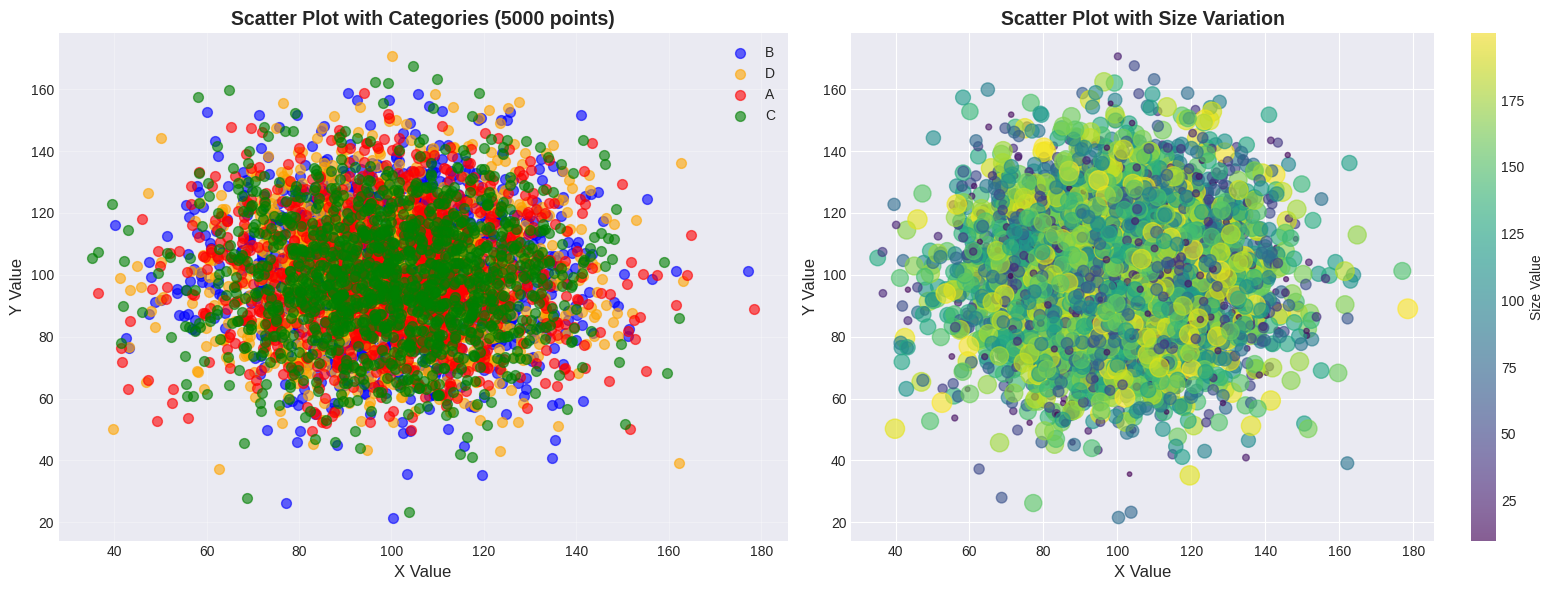

Total data points plotted: 5000


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot with color by category
colors = {'A': 'red', 'B': 'blue', 'C': 'green', 'D': 'orange'}
for category in scatter_df['Category'].unique():
    mask = scatter_df['Category'] == category
    axes[0].scatter(scatter_df[mask]['X'], scatter_df[mask]['Y'], 
                    label=category, alpha=0.6, s=50, color=colors[category])
axes[0].set_xlabel('X Value', fontsize=12)
axes[0].set_ylabel('Y Value', fontsize=12)
axes[0].set_title('Scatter Plot with Categories (5000 points)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot with size variation
scatter = axes[1].scatter(scatter_df['X'], scatter_df['Y'], 
                          c=scatter_df['Size'], s=scatter_df['Size'], 
                          alpha=0.6, cmap='viridis')
axes[1].set_xlabel('X Value', fontsize=12)
axes[1].set_ylabel('Y Value', fontsize=12)
axes[1].set_title('Scatter Plot with Size Variation', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Size Value', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Total data points plotted: {len(scatter_df)}")

## 4. Pie Chart Visualization

A pie chart represents parts of a whole. Each slice's size is proportional to its value. We can use labels, percentages, and exploded slices for emphasis.

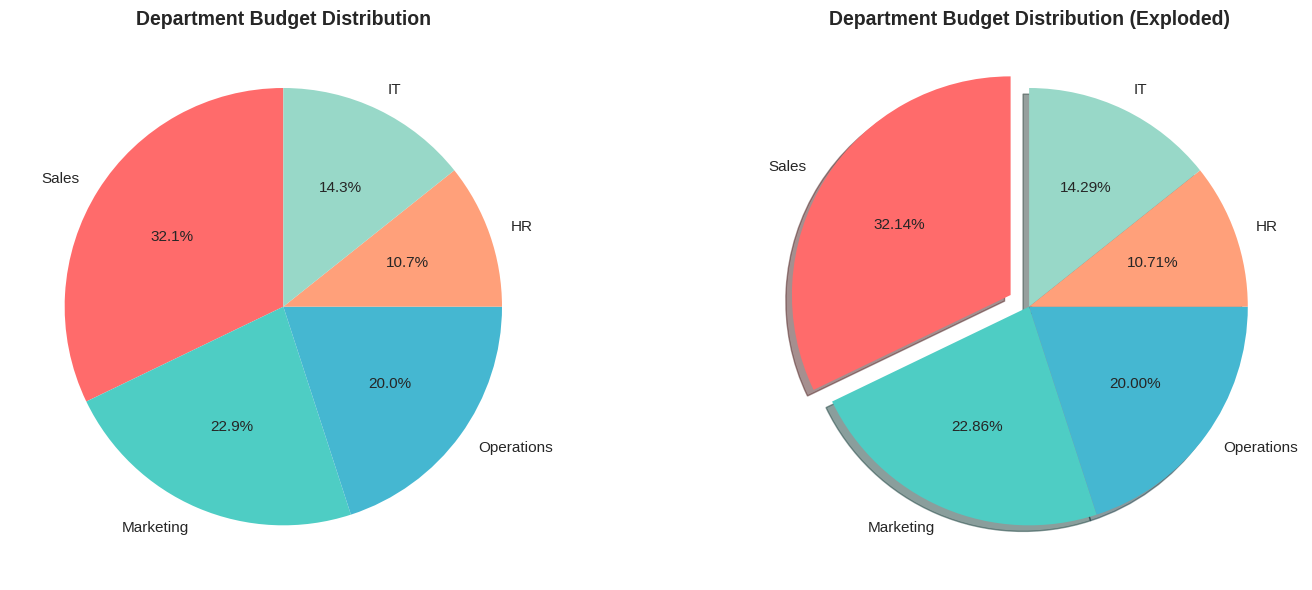

Pie Chart Data:
     Category  Value
0       Sales    450
1   Marketing    320
2  Operations    280
3          HR    150
4          IT    200

Total Value: 1400


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Basic Pie Chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
axes[0].pie(pie_df['Value'], labels=pie_df['Category'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Department Budget Distribution', fontsize=14, fontweight='bold')

# Exploded Pie Chart
explode = (0.1, 0, 0, 0, 0)
axes[1].pie(pie_df['Value'], labels=pie_df['Category'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=explode, 
            shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Department Budget Distribution (Exploded)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Pie Chart Data:")
print(pie_df)
print(f"\nTotal Value: {pie_df['Value'].sum()}")

## 5. Bar Plot Visualization

Bar plots are used for categorical data comparison. We can display vertical bars, horizontal bars, and stacked/grouped variations.

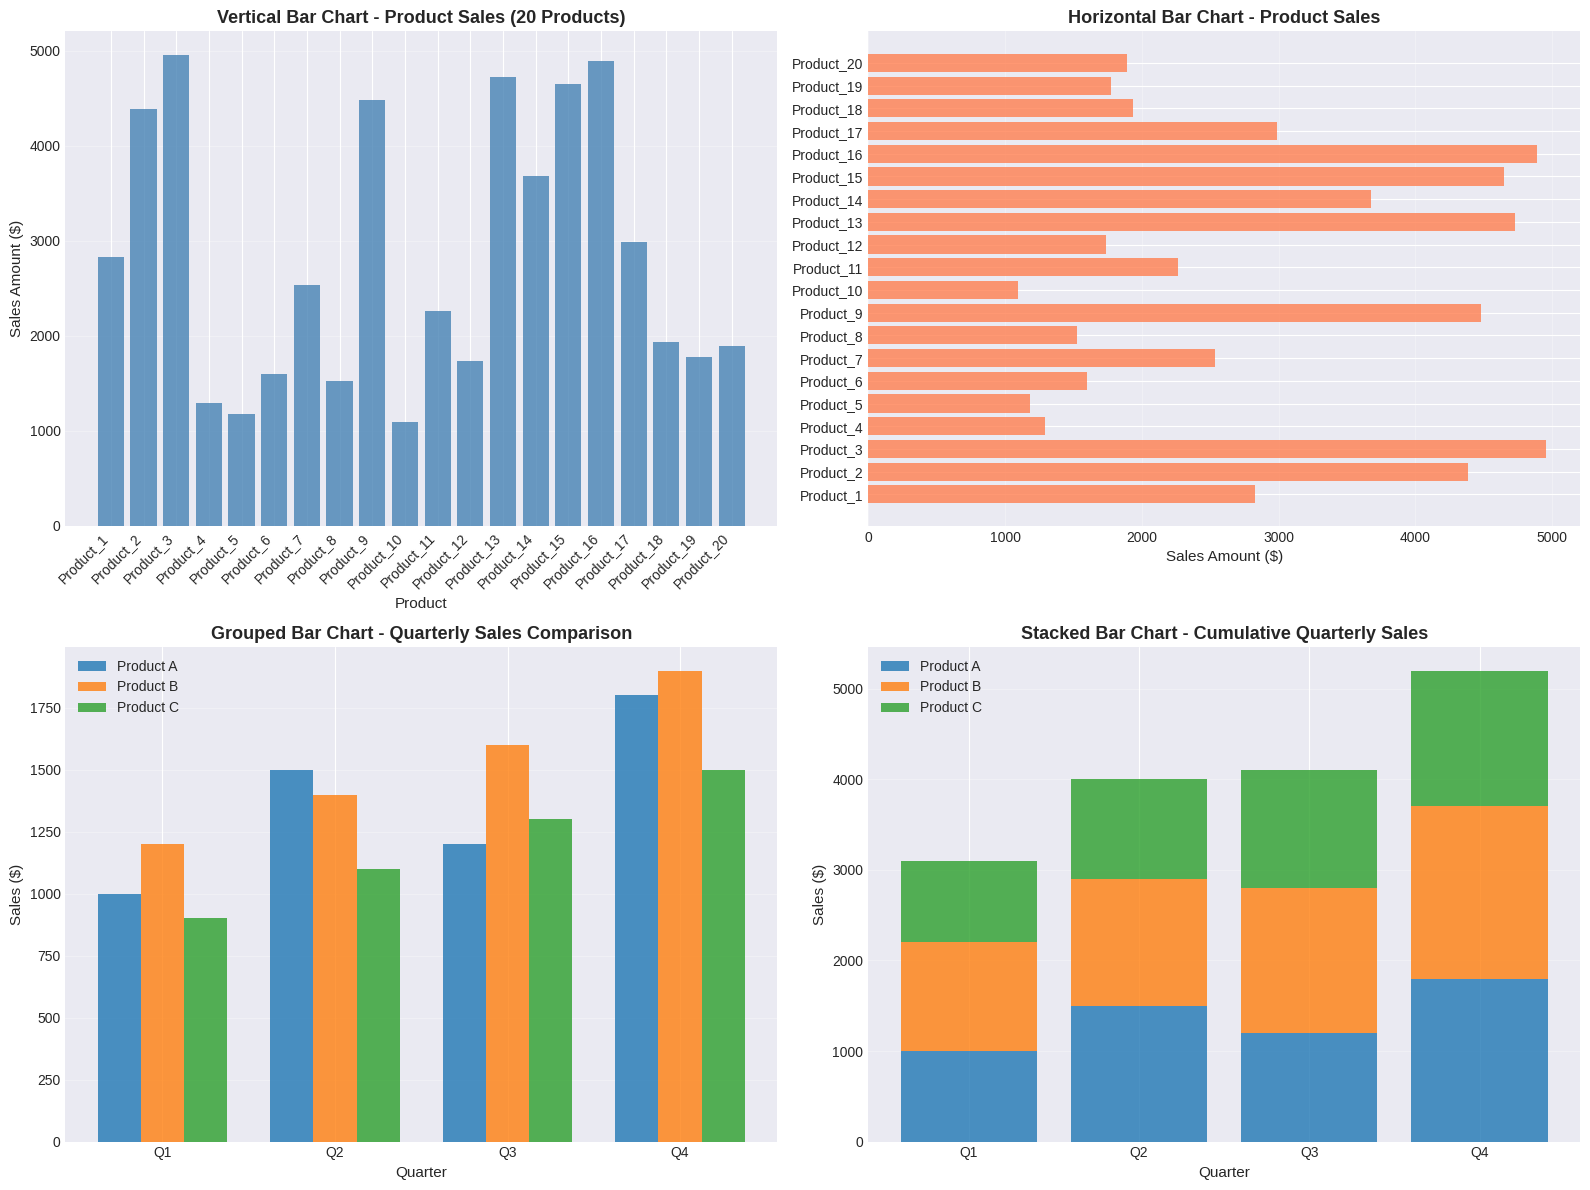

Total bar chart items displayed: 20


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vertical Bar Chart
axes[0, 0].bar(range(len(bar_df)), bar_df['Sales'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Product', fontsize=11)
axes[0, 0].set_ylabel('Sales Amount ($)', fontsize=11)
axes[0, 0].set_title('Vertical Bar Chart - Product Sales (20 Products)', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(range(len(bar_df)))
axes[0, 0].set_xticklabels(bar_df['Product'], rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)

# Horizontal Bar Chart
axes[0, 1].barh(bar_df['Product'], bar_df['Sales'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Sales Amount ($)', fontsize=11)
axes[0, 1].set_title('Horizontal Bar Chart - Product Sales', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Grouped Bar Chart
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [1000, 1500, 1200, 1800]
product_b = [1200, 1400, 1600, 1900]
product_c = [900, 1100, 1300, 1500]

x = np.arange(len(categories))
width = 0.25

axes[1, 0].bar(x - width, product_a, width, label='Product A', alpha=0.8)
axes[1, 0].bar(x, product_b, width, label='Product B', alpha=0.8)
axes[1, 0].bar(x + width, product_c, width, label='Product C', alpha=0.8)
axes[1, 0].set_xlabel('Quarter', fontsize=11)
axes[1, 0].set_ylabel('Sales ($)', fontsize=11)
axes[1, 0].set_title('Grouped Bar Chart - Quarterly Sales Comparison', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(categories)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Stacked Bar Chart
axes[1, 1].bar(categories, product_a, label='Product A', alpha=0.8)
axes[1, 1].bar(categories, product_b, bottom=product_a, label='Product B', alpha=0.8)
axes[1, 1].bar(categories, product_c, bottom=np.array(product_a)+np.array(product_b), 
               label='Product C', alpha=0.8)
axes[1, 1].set_xlabel('Quarter', fontsize=11)
axes[1, 1].set_ylabel('Sales ($)', fontsize=11)
axes[1, 1].set_title('Stacked Bar Chart - Cumulative Quarterly Sales', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total bar chart items displayed: {len(bar_df)}")

## 6. Line Graph Visualization

Line graphs are used to visualize trends over time. They are effective for showing time-series data with multiple lines and custom styling.

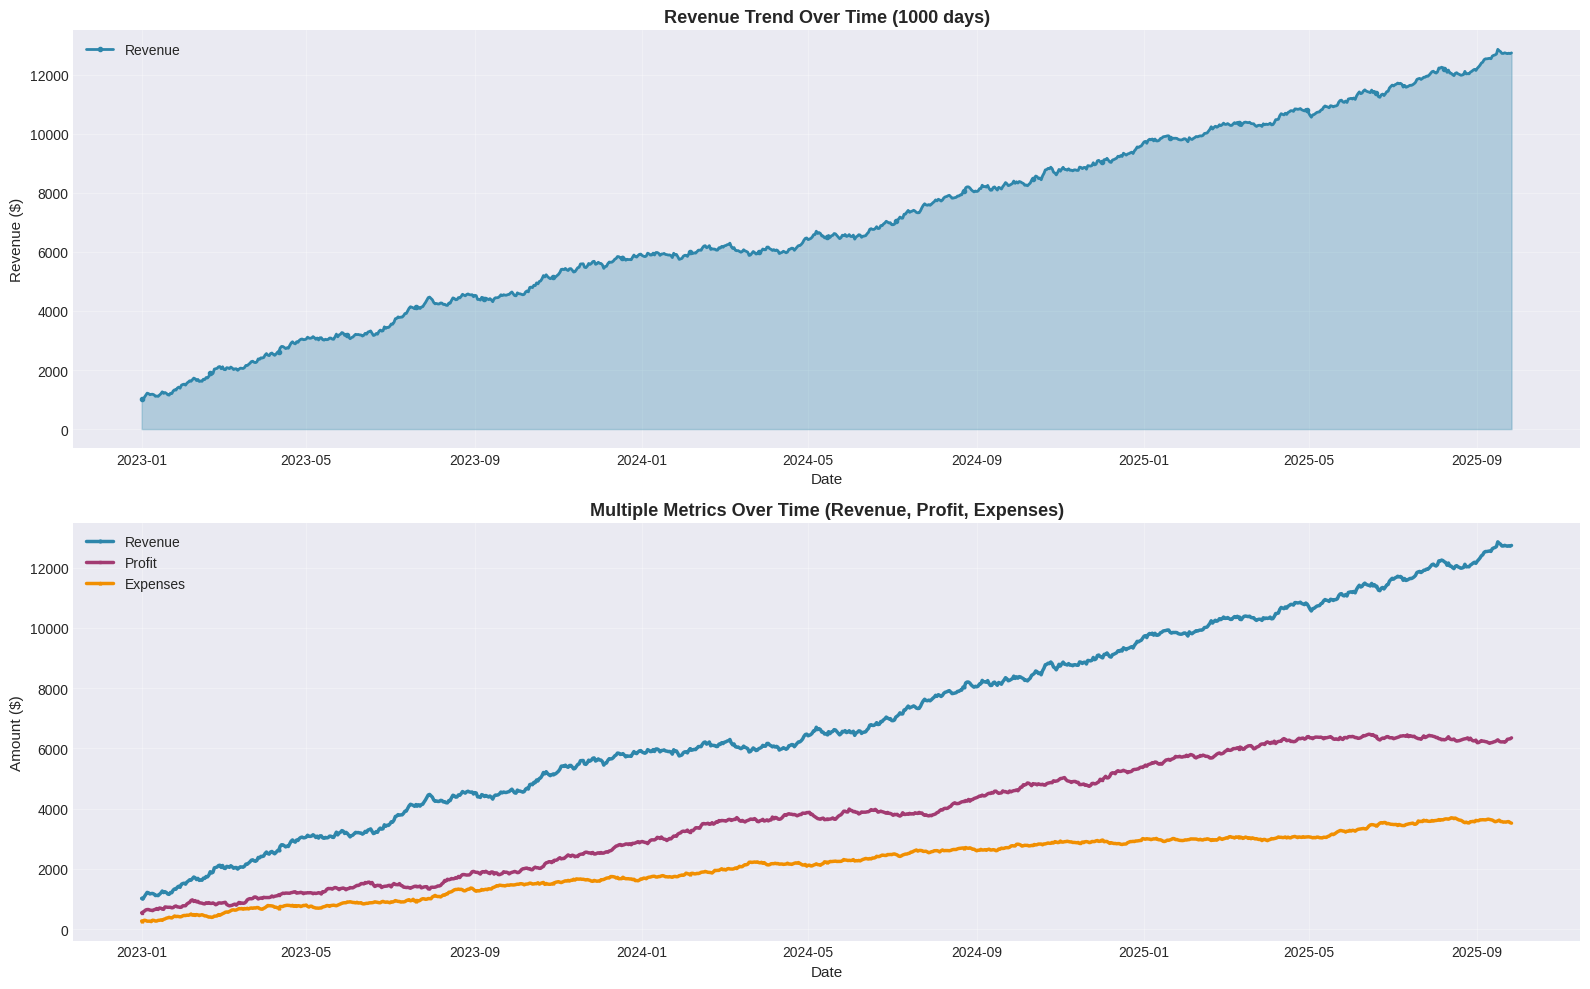

Time period: 2023-01-01 to 2025-09-26
Total data points: 1000
Revenue range: $999.11 - $12855.79


In [26]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Single Line Graph
axes[0].plot(line_df['Date'], line_df['Revenue'], linewidth=2, color='#2E86AB', label='Revenue', marker='o', markersize=3, markevery=50)
axes[0].fill_between(line_df['Date'], line_df['Revenue'], alpha=0.3, color='#2E86AB')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].set_title('Revenue Trend Over Time (1000 days)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Multiple Lines Graph
axes[1].plot(line_df['Date'], line_df['Revenue'], linewidth=2.5, label='Revenue', color='#2E86AB', marker='o', markersize=2, markevery=100)
axes[1].plot(line_df['Date'], line_df['Profit'], linewidth=2.5, label='Profit', color='#A23B72', marker='s', markersize=2, markevery=100)
axes[1].plot(line_df['Date'], line_df['Expenses'], linewidth=2.5, label='Expenses', color='#F18F01', marker='^', markersize=2, markevery=100)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Amount ($)', fontsize=11)
axes[1].set_title('Multiple Metrics Over Time (Revenue, Profit, Expenses)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Time period: {line_df['Date'].min().date()} to {line_df['Date'].max().date()}")
print(f"Total data points: {len(line_df)}")
print(f"Revenue range: ${line_df['Revenue'].min():.2f} - ${line_df['Revenue'].max():.2f}")

## 7. Histogram Visualization

Histograms display the distribution of continuous data. They are useful for understanding the frequency distribution and identifying patterns in large datasets.

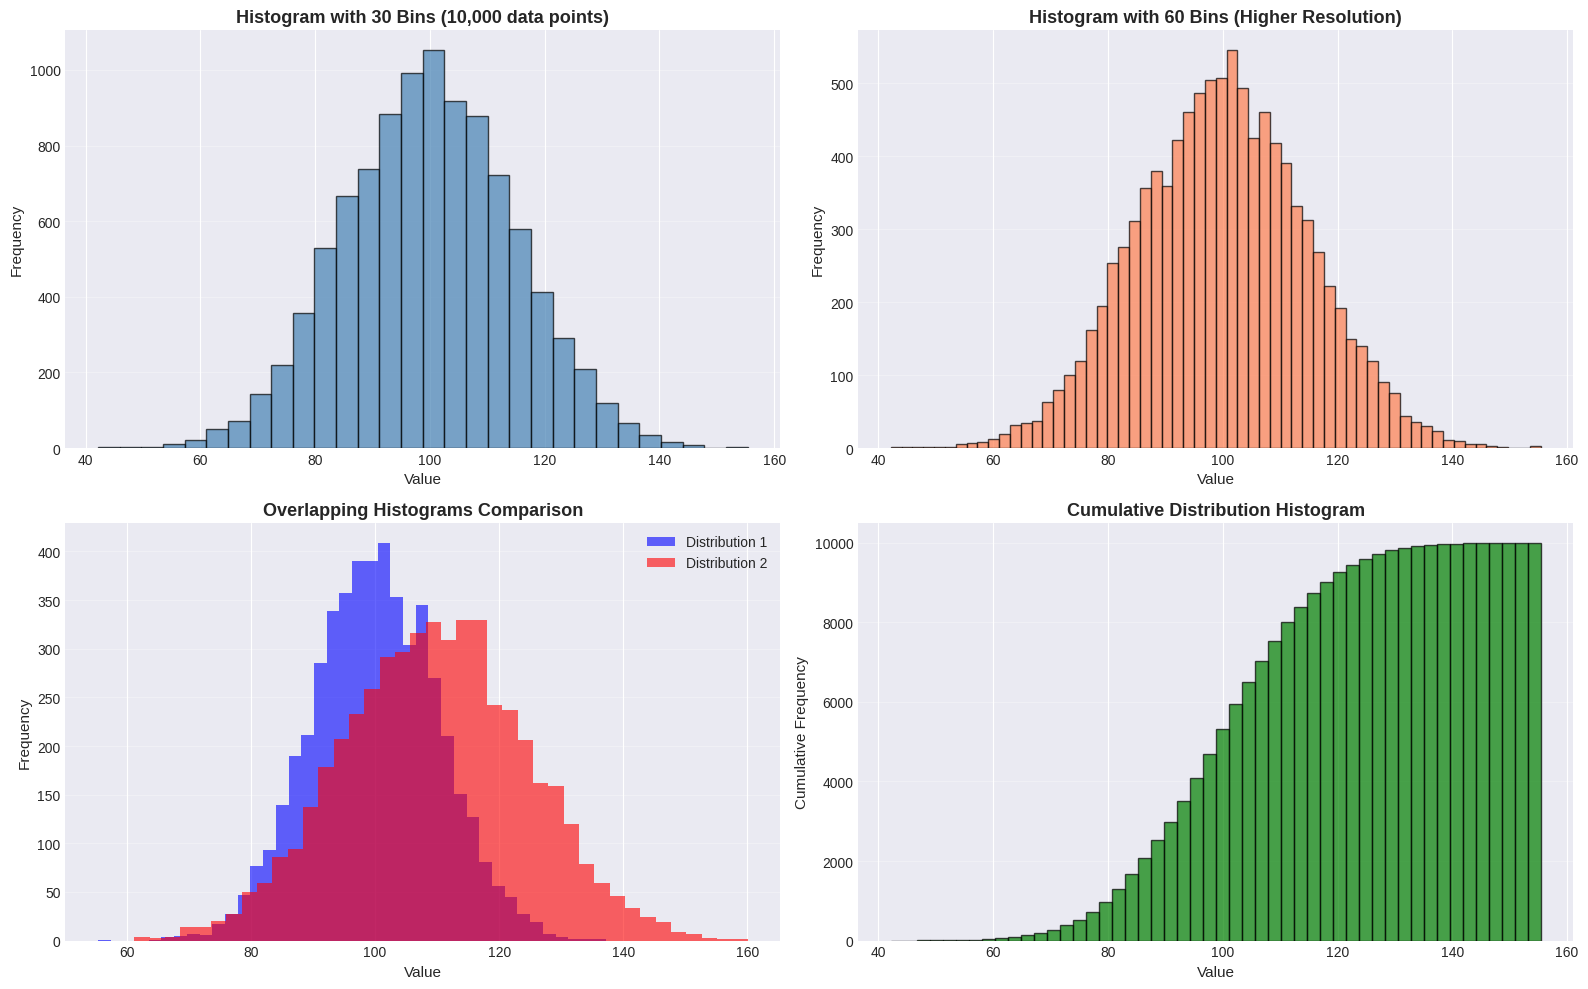

Histogram data statistics:
Total data points: 10000
Mean: 99.86
Std Dev: 14.85
Min: 42.15
Max: 155.37


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Basic Histogram with different bin sizes
axes[0, 0].hist(histogram_data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Value', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Histogram with 30 Bins (10,000 data points)', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram with more bins
axes[0, 1].hist(histogram_data, bins=60, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Value', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Histogram with 60 Bins (Higher Resolution)', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Multiple overlapping histograms
dist1 = np.random.normal(100, 10, 5000)
dist2 = np.random.normal(110, 15, 5000)
axes[1, 0].hist(dist1, bins=40, alpha=0.6, label='Distribution 1', color='blue')
axes[1, 0].hist(dist2, bins=40, alpha=0.6, label='Distribution 2', color='red')
axes[1, 0].set_xlabel('Value', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Overlapping Histograms Comparison', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Histogram with cumulative distribution
axes[1, 1].hist(histogram_data, bins=50, cumulative=True, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Value', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Frequency', fontsize=11)
axes[1, 1].set_title('Cumulative Distribution Histogram', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Histogram data statistics:")
print(f"Total data points: {len(histogram_data)}")
print(f"Mean: {histogram_data.mean():.2f}")
print(f"Std Dev: {histogram_data.std():.2f}")
print(f"Min: {histogram_data.min():.2f}")
print(f"Max: {histogram_data.max():.2f}")

## 8. Donut Chart Visualization

A donut chart is a variation of a pie chart with a hollow center. It combines the benefits of a pie chart with the ability to display text in the center.

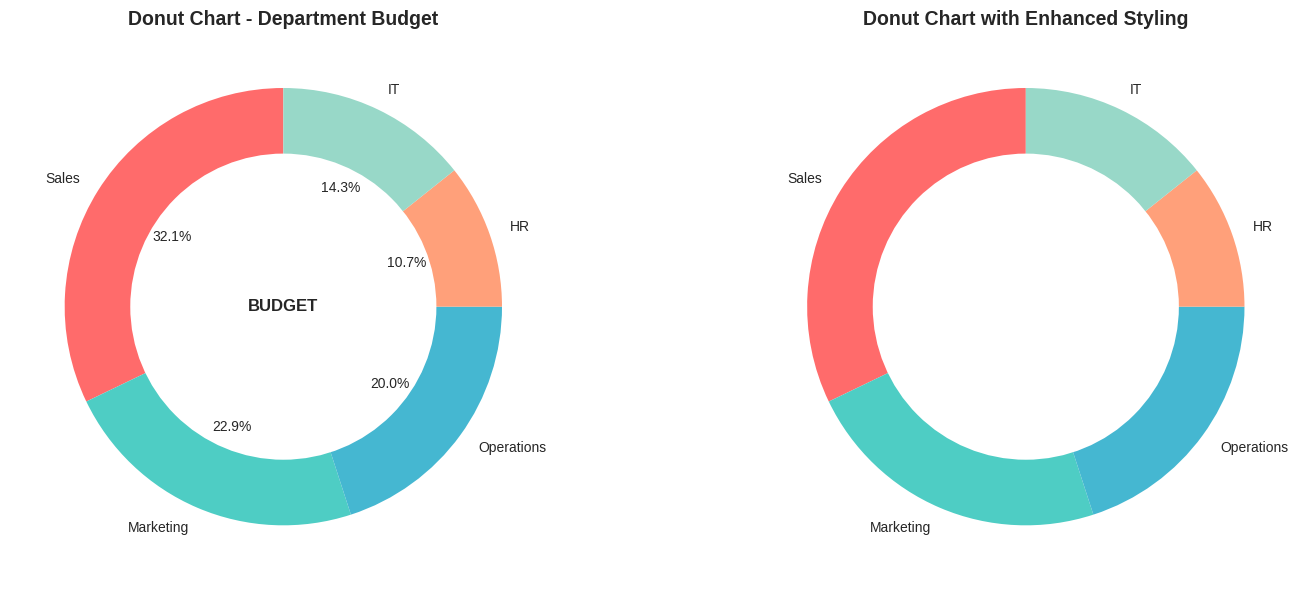

Donut Chart created successfully!
     Category  Value
0       Sales    450
1   Marketing    320
2  Operations    280
3          HR    150
4          IT    200


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Basic Donut Chart
wedges, texts, autotexts = axes[0].pie(pie_df['Value'], labels=pie_df['Category'], 
                                         autopct='%1.1f%%', colors=colors, startangle=90)
# Create hole in center
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('Donut Chart - Department Budget', fontsize=14, fontweight='bold')

# Add center text
axes[0].text(0, 0, 'BUDGET', ha='center', va='center', fontsize=12, fontweight='bold')

# Enhanced Donut Chart with legend outside
wedges, texts, autotexts = axes[1].pie(pie_df['Value'], labels=pie_df['Category'],
                                         autopct='%1.1f%%', colors=colors, startangle=90,
                                         textprops={'fontsize': 10})
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Donut Chart with Enhanced Styling', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print("Donut Chart created successfully!")
print(pie_df)

## 9. Gantt Chart Visualization

A Gantt chart is used to visualize project timelines and task schedules. Horizontal bars represent tasks with their start dates and durations.

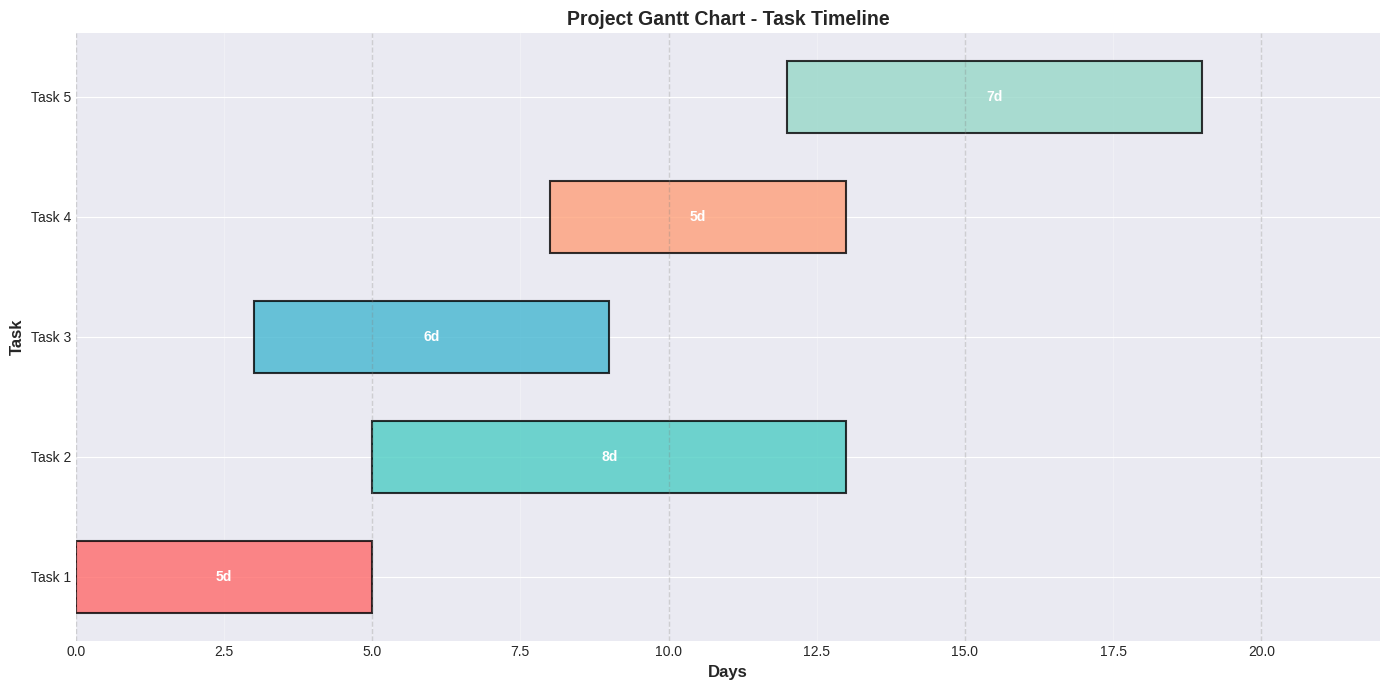

Gantt Chart Data:
     Task  Start  Duration
0  Task 1      0         5
1  Task 2      5         8
2  Task 3      3         6
3  Task 4      8         5
4  Task 5     12         7

Total project duration: 20 days


In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

# Create Gantt Chart
colors_gantt = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, task in enumerate(gantt_df['Task']):
    start = gantt_df.loc[gantt_df['Task'] == task, 'Start'].values[0]
    duration = gantt_df.loc[gantt_df['Task'] == task, 'Duration'].values[0]
    ax.barh(task, duration, left=start, height=0.6, color=colors_gantt[idx], 
            edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add duration labels on the bars
    ax.text(start + duration/2, idx, f'{duration}d', 
            va='center', ha='center', fontweight='bold', fontsize=10, color='white')

ax.set_xlabel('Days', fontsize=12, fontweight='bold')
ax.set_ylabel('Task', fontsize=12, fontweight='bold')
ax.set_title('Project Gantt Chart - Task Timeline', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, gantt_df['Start'].max() + gantt_df['Duration'].max() + 2)

# Add vertical lines for milestones
for day in range(0, 30, 5):
    ax.axvline(x=day, color='gray', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("Gantt Chart Data:")
print(gantt_df)
print(f"\nTotal project duration: {gantt_df['Start'].max() + gantt_df['Duration'].max()} days")

## 10. Waterfall Chart Visualization

A waterfall chart shows the cumulative effect of sequential positive and negative values. It clearly displays how an initial value is affected by a series of positive or negative values.

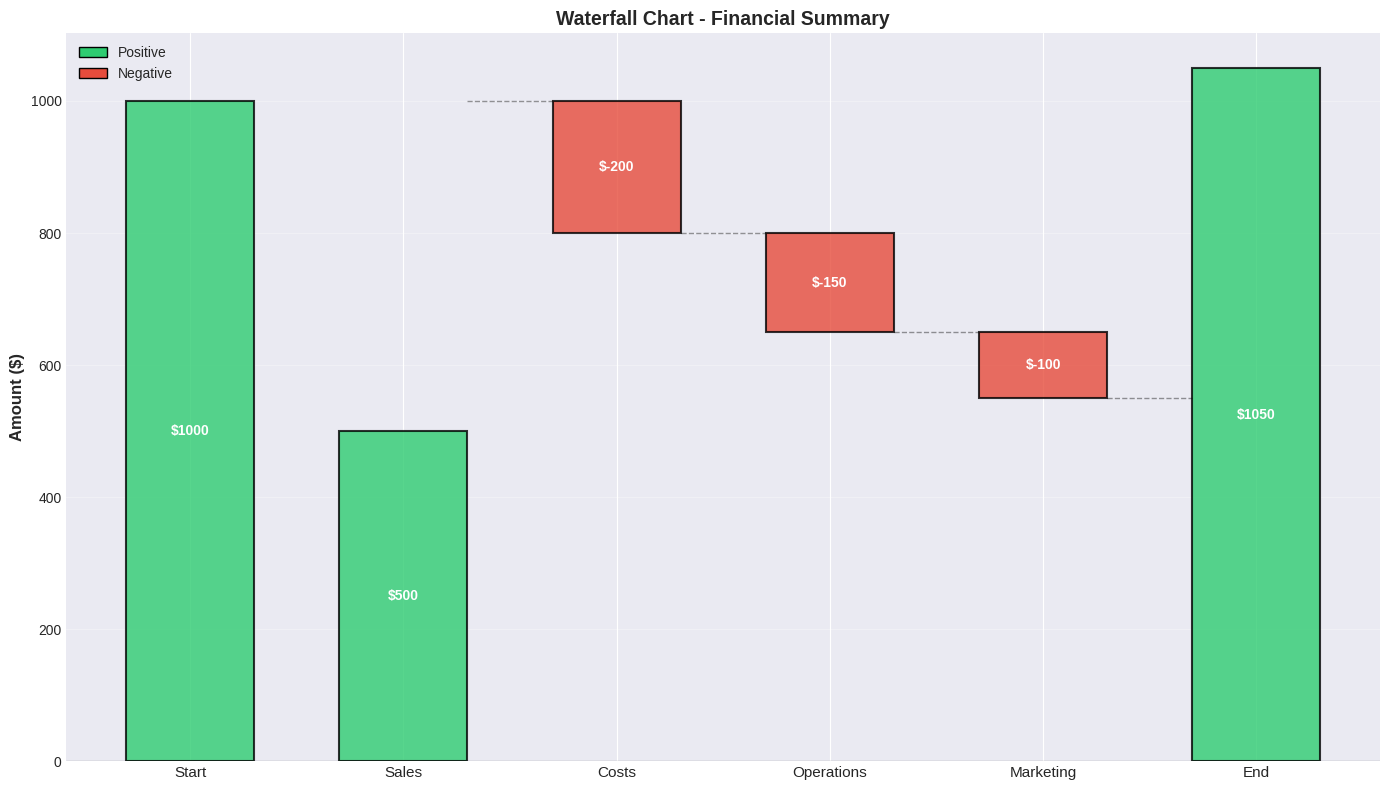

Waterfall Chart Data:
     Category  Value
0       Start   1000
1       Sales    500
2       Costs   -200
3  Operations   -150
4   Marketing   -100
5         End   1050

Starting Value: $1000
Final Value: $1050
Net Change: $50


In [30]:
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for waterfall chart
categories = waterfall_df['Category'].tolist()
values = waterfall_df['Value'].tolist()

# Calculate cumulative values for positioning
cumulative = [0]
for i in range(len(values) - 1):
    if i == 0:
        cumulative.append(values[0])
    else:
        cumulative.append(cumulative[-1] + values[i+1])

# Create waterfall chart
colors = []
for val in values:
    if val >= 0:
        colors.append('#2ECC71')  # Green for positive
    else:
        colors.append('#E74C3C')  # Red for negative

# Plot bars
x_pos = np.arange(len(categories))
for i, (cat, val) in enumerate(zip(categories, values)):
    if i == 0:  # Starting value
        ax.bar(i, val, color=colors[i], edgecolor='black', linewidth=1.5, alpha=0.8, width=0.6)
        ax.text(i, val/2, f'${val}', ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    elif i == len(categories) - 1:  # Ending value
        ax.bar(i, val, color=colors[i], edgecolor='black', linewidth=1.5, alpha=0.8, width=0.6)
        ax.text(i, val/2, f'${val}', ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    else:  # Middle values
        if val >= 0:
            bottom = cumulative[i-1]
            ax.bar(i, val, bottom=bottom, color=colors[i], edgecolor='black', linewidth=1.5, alpha=0.8, width=0.6)
            ax.text(i, bottom + val/2, f'${val}', ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        else:
            bottom = cumulative[i-1] + val
            ax.bar(i, abs(val), bottom=bottom, color=colors[i], edgecolor='black', linewidth=1.5, alpha=0.8, width=0.6)
            ax.text(i, bottom + abs(val)/2, f'${val}', ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        
        # Draw connector lines
        if i < len(categories) - 1:
            ax.plot([i + 0.3, i + 0.7], [cumulative[i], cumulative[i]], 'k--', alpha=0.4, linewidth=1)

ax.set_ylabel('Amount ($)', fontsize=12, fontweight='bold')
ax.set_title('Waterfall Chart - Financial Summary', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ECC71', edgecolor='black', label='Positive'),
                   Patch(facecolor='#E74C3C', edgecolor='black', label='Negative')]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

print("Waterfall Chart Data:")
print(waterfall_df)
print(f"\nStarting Value: ${values[0]}")
print(f"Final Value: ${values[-1]}")
print(f"Net Change: ${values[-1] - values[0]}")

## Summary

This notebook has covered 8 major data visualization types using Matplotlib:

1. **Scatter Plot**: Best for showing relationships between two continuous variables. Useful for identifying correlations and outliers.

2. **Pie Chart**: Ideal for displaying parts of a whole. Easy to understand percentages but limited to small number of categories.

3. **Bar Plot**: Effective for comparing categorical data. Available in vertical, horizontal, grouped, and stacked variants.

4. **Line Graph**: Perfect for showing trends over time. Excellent for time-series data with multiple lines for comparisons.

5. **Histogram**: Used for displaying the distribution of continuous data. Helps identify patterns and frequency distributions.

6. **Donut Chart**: A variation of pie charts with a hollow center, often used for modern dashboard designs.

7. **Gantt Chart**: Ideal for project management and timeline visualization. Shows task durations and dependencies.

8. **Waterfall Chart**: Shows the cumulative effect of positive and negative values. Excellent for financial analysis.

### Key Takeaways:
- Choose the right visualization type based on your data and audience
- Always label your axes and provide meaningful titles
- Use colors strategically to highlight important information
- Consider accessibility when choosing color schemes
- Large datasets benefit from proper aggregation and sampling
- Combine multiple visualization types for comprehensive analysis